In [71]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [72]:
dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
df['target'] = y_label
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [73]:
print(dataset.target_names)
print(df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [74]:
X_features = df.iloc[:,:-1]
y_label = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,
                                                    test_size=0.2, random_state=42)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                                            test_size=0.1, random_state=42)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [75]:
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [76]:
params = {
    'max_depth': 3,
    'eta': 0.05,
    'objective': 'binary:logistic',
    'eval_metrics': 'logloss'
}

num_rounds = 400

In [77]:
eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(params=params,
                      dtrain=dtr,
                      num_boost_round=num_rounds,
                      early_stopping_rounds=50,
                      evals=eval_list)

[0]	train-logloss:0.62050	eval-logloss:0.61001
[1]	train-logloss:0.58330	eval-logloss:0.57461
[2]	train-logloss:0.54934	eval-logloss:0.54007
[3]	train-logloss:0.51841	eval-logloss:0.50875
[4]	train-logloss:0.49004	eval-logloss:0.48189
[5]	train-logloss:0.46404	eval-logloss:0.45641
[6]	train-logloss:0.44039	eval-logloss:0.43442
[7]	train-logloss:0.41812	eval-logloss:0.41272
[8]	train-logloss:0.39753	eval-logloss:0.39276
[9]	train-logloss:0.37838	eval-logloss:0.37423
[10]	train-logloss:0.36021	eval-logloss:0.35946
[11]	train-logloss:0.34335	eval-logloss:0.34598
[12]	train-logloss:0.32791	eval-logloss:0.33184
[13]	train-logloss:0.31279	eval-logloss:0.31619
[14]	train-logloss:0.29911	eval-logloss:0.30469
[15]	train-logloss:0.28613	eval-logloss:0.29152
[16]	train-logloss:0.27361	eval-logloss:0.27841
[17]	train-logloss:0.26225	eval-logloss:0.26918
[18]	train-logloss:0.25147	eval-logloss:0.25958
[19]	train-logloss:0.24100	eval-logloss:0.24849
[20]	train-logloss:0.23145	eval-logloss:0.23940
[2

In [78]:
pred_prob = xgb_model.predict(dtest)
print(np.round(pred_prob[:10], 3))

pred = [ 1 if x > 0.5 else 0 for x in pred_prob ]
print(pred[:10])

[0.992 0.001 0.001 1.    1.    0.001 0.001 0.137 0.209 0.999]
[1, 0, 0, 1, 1, 0, 0, 0, 0, 1]


In [79]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, roc_curve

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('Confusion Matrix', confusion)
    print('정확도:', accuracy, '정밀도:', precision, '재현율:', recall, 'f1 score:', f1, 'auc:', roc_auc)

get_clf_eval(y_test, pred, pred_prob)

Confusion Matrix [[40  3]
 [ 2 69]]
정확도: 0.956140350877193 정밀도: 0.9583333333333334 재현율: 0.971830985915493 f1 score: 0.965034965034965 auc: 0.9937766131673763


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

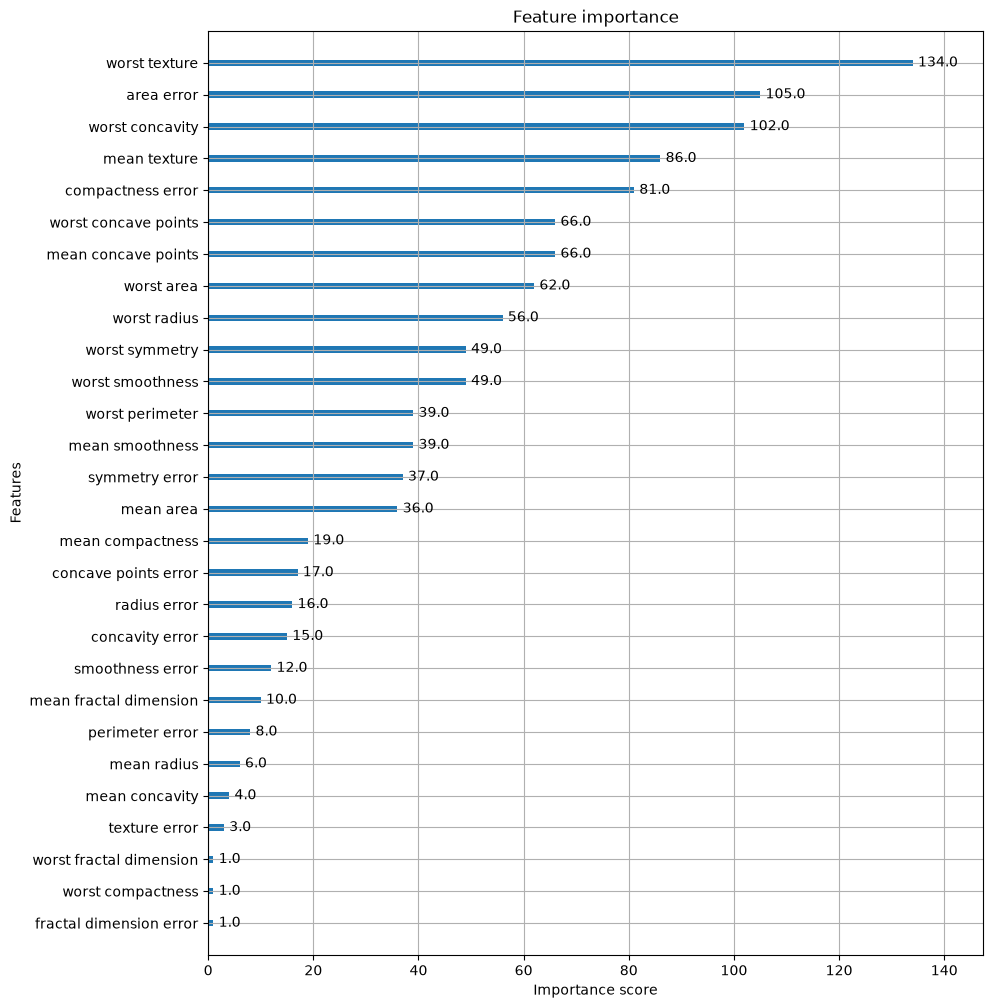

In [80]:
import matplotlib.pyplot as plt

flg, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

In [81]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1,
                            max_depth=3)

xgb_wrapper.fit(X_train, y_train)
w_pred = xgb_wrapper.predict(X_test)
w_pred_prob = xgb_wrapper.predict_proba(X_test)[:,1]

In [82]:
get_clf_eval(y_test, w_pred, w_pred_prob)

Confusion Matrix [[40  3]
 [ 2 69]]
정확도: 0.956140350877193 정밀도: 0.9583333333333334 재현율: 0.971830985915493 f1 score: 0.965034965034965 auc: 0.9931215198165738


In [83]:
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1,
                            max_depth=3,
                            early_stopping_rounds=100,
                            eval_metic='logloss')
evals = [(X_test, y_test)]

xgb_wrapper.fit(X_train, y_train,
                eval_set = evals,
                verbose=True)

preds = xgb_wrapper.predict(X_test)
preds_prob = xgb_wrapper.predict_proba(X_test)[:,1]

[0]	validation_0-logloss:0.58703
[1]	validation_0-logloss:0.52197
[2]	validation_0-logloss:0.47245
[3]	validation_0-logloss:0.42712
[4]	validation_0-logloss:0.39031
[5]	validation_0-logloss:0.35649
[6]	validation_0-logloss:0.32948
[7]	validation_0-logloss:0.30458
[8]	validation_0-logloss:0.28250
[9]	validation_0-logloss:0.26495
[10]	validation_0-logloss:0.24991
[11]	validation_0-logloss:0.23415
[12]	validation_0-logloss:0.21702
[13]	validation_0-logloss:0.20725
[14]	validation_0-logloss:0.19693
[15]	validation_0-logloss:0.18517
[16]	validation_0-logloss:0.17394
[17]	validation_0-logloss:0.16896
[18]	validation_0-logloss:0.16154
[19]	validation_0-logloss:0.15789
[20]	validation_0-logloss:0.15420
[21]	validation_0-logloss:0.14766
[22]	validation_0-logloss:0.14149
[23]	validation_0-logloss:0.13834
[24]	validation_0-logloss:0.13597
[25]	validation_0-logloss:0.13191
[26]	validation_0-logloss:0.13036
[27]	validation_0-logloss:0.12971
[28]	validation_0-logloss:0.12726
[29]	validation_0-loglos

In [84]:
get_clf_eval(y_test, preds, preds_prob)

Confusion Matrix [[40  3]
 [ 2 69]]
정확도: 0.956140350877193 정밀도: 0.9583333333333334 재현율: 0.971830985915493 f1 score: 0.965034965034965 auc: 0.9944317065181788
